In [1]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("assets/data/placement.csv")

In [10]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


now we have an uneccessary column here "Unnamed". So we need to preprocess this data file.

In [11]:
df.shape

(100, 4)

### Steps

 0. Preprocess + EDA + Feature Selection
 1. Extract input and output cols
 2. Scale the values
 3. Train test split
 4. Train the model
 5. Evaluate the model/model selection
 6. Deploy the model

In [13]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [14]:
df = df.iloc[:,1:]

In [15]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


So we have preprocessed our data by removing the undesired column

In [16]:
import matplotlib.pyplot as plt


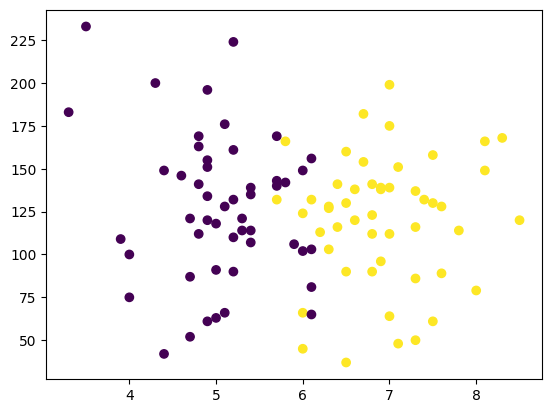

In [17]:
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])

This completes our Exploratory data analysis or EDA.

We will use logistic regression here.

In [ ]:
X = df.iloc[:,0:2]  #All independent variables, cgpa & iq
Y = df.iloc[:,-1]   #dependent variable placement

In [19]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [20]:
Y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

This marks the completion of exraction of input and output cols

Now we will split the data into training data and testing data. This is very crucial since we need data for testing our model

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.1) # 0.1 means 10% of the data will go to testing


In [23]:
X_test

,cgpa,iq
32,7.0,139.0
39,4.6,146.0
5,7.1,48.0
31,3.9,109.0
16,5.2,224.0
87,5.7,132.0
56,6.1,65.0
83,7.5,130.0
15,5.1,176.0
25,5.0,91.0


In [24]:
Y_test

32    1
39    0
5     1
31    0
16    0
87    1
56    0
83    1
15    0
25    0
Name: placement, dtype: int64

so we have successfully segregated our data into training and testing data.
Now we will scale our data.

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [27]:
X_train = scaler.fit_transform(X_train)

In [28]:
X_train

array([[ 1.39031446,  0.12158589],
       [ 0.95003191,  0.71799058],
       [-1.77971991, -1.25273799],
       [-0.72304179, -0.34516562],
       [ 0.33363633,  0.45868419],
       [-0.98721132,  0.27716972],
       [ 2.00671003,  1.15881145],
       [ 0.42169284,  0.17344716],
       [ 0.24557982,  0.12158589],
       [-0.8110983 ,  0.12158589],
       [ 1.21420144,  0.22530844],
       [-0.98721132, -0.08585923],
       [-1.42749387, -2.10844908],
       [ 1.7425405 , -1.14901543],
       [ 0.0694668 , -1.09715415],
       [ 0.24557982, -0.52668009],
       [-0.98721132,  0.71799058],
       [-1.16332434, -1.84914269],
       [-0.01858971,  0.66612931],
       [-2.22000247,  2.84430299],
       [-1.77971991, -0.60447201],
       [-0.01858971, -2.03065716],
       [-0.01858971, -1.48611374],
       [ 1.83059701,  0.66612931],
       [ 0.24557982,  0.09565525],
       [-0.54692877,  0.30310036],
       [ 0.77391889, -0.70819457],
       [ 0.0694668 , -0.52668009],
       [-0.72304179,

In [29]:
X_test = scaler.transform(X_test)

In [30]:
X_test

array([[ 0.8619754 ,  0.40682292],
       [-1.25138085,  0.58833739],
       [ 0.95003191, -1.95286524],
       [-1.86777642, -0.37109626],
       [-0.72304179,  2.61092724],
       [-0.28275924,  0.22530844],
       [ 0.0694668 , -1.51204438],
       [ 1.30225795,  0.17344716],
       [-0.8110983 ,  1.36625656],
       [-0.89915481, -0.83784776]])

Now we will train the model. we have decided to use logistic regression

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
clf = LogisticRegression()

In [33]:
# model training
clf.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

Now time to evaluate our model


In [ ]:
Y_pred = clf.predict(X_test)

In [37]:
Y_pred

array([1, 0, 1, 0, 0, 0, 1, 1, 0, 0])

In [35]:
Y_test

32    1
39    0
5     1
31    0
16    0
87    1
56    0
83    1
15    0
25    0
Name: placement, dtype: int64

In [38]:
from sklearn.metrics import accuracy_score

In [39]:
accuracy_score(Y_test,Y_pred)

0.8

This means that our model predicted correct placements for 8 students out of 10.\
Now we need to plot the decision region for our model\
Plotting decision regions helps us visualize what a machine learning model has learned.

In [42]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

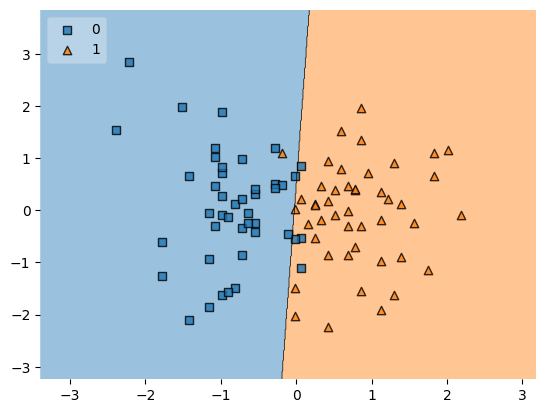

In [44]:
plot_decision_regions(X_train,Y_train.values ,clf=clf,legend =2)

Now if we want we can go back and make changes in our model to get the desired accuracy.
Now we will focus on deployment of our model.
For that we will use pickle.\
The pickle library in Python is used to save Python objects to a file and load them back later.

Think of it as:

"Freeze a Python object and store it on disk so you can use it again without recreating or retraining it."

In [45]:
import pickle

In [47]:
pickle.dump(clf,open('model.pkl','wb'))

now just take the pkl file and deploy it on your website.\
So we saw overall steps involved in training and deployment of a model.